# IV. PHẦN 3 – GARCH(1,1)

Mô hình hóa conditional volatility của XOM bằng GARCH(1,1), kiểm định ARCH effect và làm rõ giới hạn của dự báo GARCH.

**Lưu ý:** toàn bộ tính toán dùng log-return nhân 100 (đơn vị %), nên phương sai có đơn vị %² và độ lệch chuẩn có đơn vị %. Cần cài thư viện `arch` (`pip install arch`).

In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib-cache"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from arch import arch_model

os.makedirs("../figures", exist_ok=True)

df = pd.read_csv("../data/XOM_SP500_2024_2026.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

r = df["XOM_Return"] * 100          # XOM log-return (%)
m = df["SP500_Return"] * 100        # S&P 500 log-return (%)

print("Số quan sát:", len(r))
print("Giai đoạn:", r.index.min().date(), "đến", r.index.max().date())
df.head()

Số quan sát: 686
Giai đoạn: 2024-01-03 đến 2026-09-28


,XOM,SP500,XOM_Return,SP500_Return
Date,,,,
2024-01-03,94.388016,4704.810059,0.008367,-0.008049
2024-01-04,93.565025,4688.680176,-0.008757,-0.003434
2024-01-05,93.848495,4697.240234,0.003025,0.001824
2024-01-08,92.284821,4763.540039,-0.016802,0.014016
2024-01-09,91.141777,4756.500000,-0.012463,-0.001479


## 4.1. Conditional vs Unconditional Variance

- **Unconditional variance**: phương sai dài hạn, tính trên toàn mẫu và coi là hằng số: σ² = Var(rₜ).
- **Conditional variance**: phương sai của rₜ khi đã biết thông tin đến t−1: σₜ² = Var(rₜ | Ωₜ₋₁), thay đổi theo thời gian.
- OLS ở Phần 1 giả định phương sai sai số không đổi (gần với unconditional), còn GARCH cho phép σₜ² thay đổi.

Unconditional variance : 2.2010 (%²)
Unconditional std. dev.: 1.4836 (%/ngày)


,Std. Dev. (%)
Date,
2024,1.2062
2025,1.4837
2026,1.7960


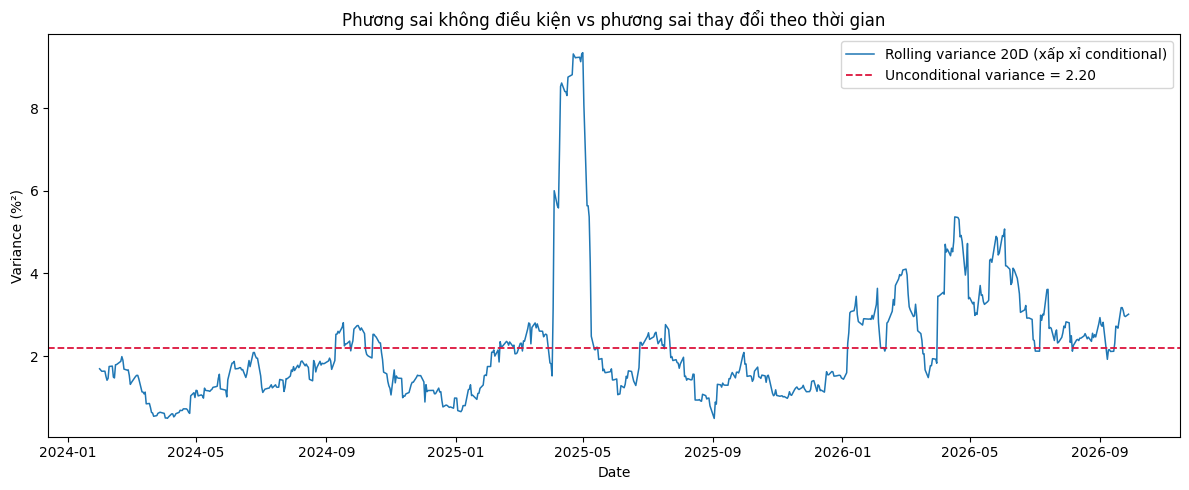

In [2]:
uncond_var = r.var()
uncond_sd = r.std()
print(f"Unconditional variance : {uncond_var:.4f} (%²)")
print(f"Unconditional std. dev.: {uncond_sd:.4f} (%/ngày)")

yearly_sd = r.groupby(r.index.year).std().to_frame("Std. Dev. (%)")
display(yearly_sd.round(4))

# So sánh phương sai không đổi với phương sai thay đổi theo thời gian (rolling 20 ngày)
roll_var = r.rolling(20).var()

plt.figure(figsize=(12, 5))
plt.plot(roll_var, linewidth=1.1, label="Rolling variance 20D (xấp xỉ conditional)")
plt.axhline(uncond_var, color="crimson", linestyle="--", linewidth=1.3,
            label=f"Unconditional variance = {uncond_var:.2f}")
plt.title("Phương sai không điều kiện vs phương sai thay đổi theo thời gian")
plt.xlabel("Date")
plt.ylabel("Variance (%²)")
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:** phương sai không điều kiện là một hằng số duy nhất, trong khi phương sai tính theo cửa sổ 20 ngày dao động rất mạnh quanh mức đó (đỉnh vào tháng 04–05/2025). Độ lệch chuẩn theo năm cũng tăng từ 2024 đến 2026. Một giá trị phương sai cố định vì vậy không mô tả đủ rủi ro của XOM, đây là lý do cần mô hình phương sai có điều kiện.

## 4.2. Kiểm tra ARCH Effect

- **ARCH-LM (Engle, 1982):** H₀: không có ARCH effect; H₁: có ARCH effect. Nếu p-value < 0,05 thì bác bỏ H₀.
- **Ljung-Box trên bình phương phần dư:** kiểm tra tự tương quan của eₜ².
- Chạy thêm ARCH-LM trên phần dư OLS (XOM ~ S&P 500) để nối với Phần 1.

In [3]:
resid = r - r.mean()                         # phần dư của mô hình trung bình hằng số

rows = []
for nl in [1, 5, 10]:
    lm, lm_p, f, f_p = het_arch(resid, nlags=nl)
    rows.append([f"ARCH-LM ({nl} lags)", "Return đã trừ trung bình", lm, lm_p])

ols = sm.OLS(r, sm.add_constant(m)).fit()
lm, lm_p, f, f_p = het_arch(ols.resid, nlags=5)
rows.append(["ARCH-LM (5 lags)", "Phần dư OLS (Phần 1)", lm, lm_p])

lb = acorr_ljungbox(resid**2, lags=[5, 10, 20], return_df=True)
for lag, (q, p) in lb.iterrows():
    rows.append([f"Ljung-Box (lag {lag})", "Bình phương phần dư", q, p])

arch_tests = pd.DataFrame(rows, columns=["Kiểm định", "Đối tượng", "Thống kê", "p-value"])
display(arch_tests.style.format({"Thống kê": "{:.3f}", "p-value": "{:.2e}"}))

lm5, p5 = het_arch(resid, nlags=5)[:2]
if p5 < 0.05:
    print(f"ARCH-LM (5 lags): p-value = {p5:.2e} < 0.05 → bác bỏ H0, chuỗi XOM có ARCH effect.")
else:
    print(f"ARCH-LM (5 lags): p-value = {p5:.4f} ≥ 0.05 → chưa đủ bằng chứng về ARCH effect.")

,Kiểm định,Đối tượng,Thống kê,p-value
0,ARCH-LM (1 lags),Return đã trừ trung bình,19.639,9.35e-06
1,ARCH-LM (5 lags),Return đã trừ trung bình,59.866,1.30e-11
2,ARCH-LM (10 lags),Return đã trừ trung bình,66.032,2.57e-10
3,ARCH-LM (5 lags),Phần dư OLS (Phần 1),36.224,8.57e-07
4,Ljung-Box (lag 5),Bình phương phần dư,78.085,2.11e-15
5,Ljung-Box (lag 10),Bình phương phần dư,81.216,2.90e-13
6,Ljung-Box (lag 20),Bình phương phần dư,97.167,4.03e-12


ARCH-LM (5 lags): p-value = 1.30e-11 < 0.05 → bác bỏ H0, chuỗi XOM có ARCH effect.


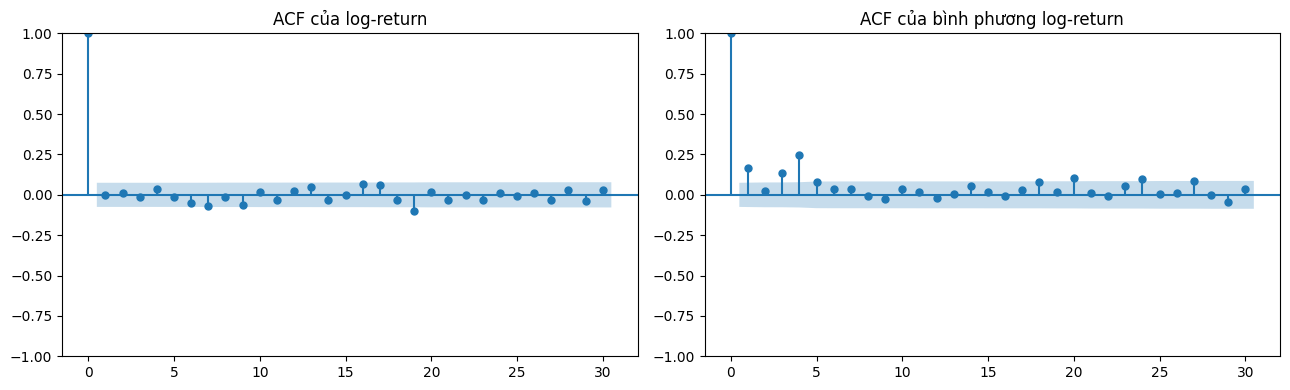

In [4]:
# ACF của return và bình phương return
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(r, lags=30, ax=ax[0], title="ACF của log-return")
plot_acf(r**2, lags=30, ax=ax[1], title="ACF của bình phương log-return")
plt.tight_layout()
plt.savefig("../figures/hinh_acf.png", dpi=200)
plt.show()

**Nhận xét:** tất cả p-value đều nhỏ hơn 0,001 nên bác bỏ H₀, chuỗi XOM_Return có ARCH effect. Kết quả này xác nhận bằng kiểm định thống kê dấu hiệu volatility clustering ở Phần 2. ARCH-LM trên phần dư OLS của Phần 1 vẫn có ý nghĩa, tức phương sai sai số của mô hình OLS không đổi là giả định không thỏa mãn. ACF của r² có tự tương quan dương kéo dài trong khi ACF của r gần như không có, cho thấy độ lớn biến động phụ thuộc theo thời gian dù hướng biến động khó dự đoán.

## 4.3. Xây dựng GARCH(1,1)

**Phương trình trung bình:** rₜ = μ + εₜ,  εₜ = σₜzₜ,  zₜ ~ i.i.d. N(0,1)

**Phương trình phương sai:** σₜ² = ω + α₁εₜ₋₁² + β₁σₜ₋₁²

- ω: mức phương sai nền; α₁: phản ứng với cú sốc của phiên trước (ARCH); β₁: quán tính của phương sai cũ (GARCH).
- Ràng buộc: ω > 0, α₁ ≥ 0, β₁ ≥ 0, α₁ + β₁ < 1 (chuỗi dừng).
- Ước lượng bằng Maximum Likelihood, sai số chuẩn vững (mặc định của `arch`), phương trình trung bình là hằng số.

In [5]:
am = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = am.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             XOM_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1225.93
Distribution:                  Normal   AIC:                           2459.85
Method:            Maximum Likelihood   BIC:                           2477.98
                                        No. Observations:                  686
Date:                Wed, Sep 30 2026   Df Residuals:                      685
Time:                        06:27:37   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0665  5.504e-02      1.207      0.227 [-4.14

## 4.4. Phân tích tham số

In [6]:
params = pd.DataFrame({
    "Hệ số": res.params,
    "Sai số chuẩn": res.std_err,
    "z-stat": res.tvalues,
    "p-value": res.pvalues,
})
params.index = ["μ", "ω", "α₁", "β₁"]
display(params.style.format({"Hệ số": "{:.4f}", "Sai số chuẩn": "{:.4f}",
                             "z-stat": "{:.3f}", "p-value": "{:.4f}"}))
print(f"Log-Likelihood = {res.loglikelihood:.2f} | AIC = {res.aic:.2f} | BIC = {res.bic:.2f}")

omega, alpha, beta = res.params["omega"], res.params["alpha[1]"], res.params["beta[1]"]
persistence = alpha + beta
half_life = np.log(0.5) / np.log(persistence)
lr_var = omega / (1 - persistence)

summary = pd.DataFrame({
    "Giá trị": [persistence, half_life, lr_var, np.sqrt(lr_var), uncond_var, uncond_sd]
}, index=["Persistence (α₁+β₁)", "Half-life (ngày)", "Phương sai dài hạn (%²)",
          "Độ lệch chuẩn dài hạn (%/ngày)", "Phương sai mẫu (%²)", "Độ lệch chuẩn mẫu (%/ngày)"])
display(summary.round(4))
print("Điều kiện dừng α₁+β₁ < 1:", "thỏa" if persistence < 1 else "KHÔNG thỏa")

,Hệ số,Sai số chuẩn,z-stat,p-value
μ,0.0665,0.0550,1.207,0.2273
ω,0.0461,0.0358,1.288,0.1977
α₁,0.0415,0.0200,2.080,0.0375
β₁,0.9384,0.0306,30.637,0.0000


Log-Likelihood = -1225.93 | AIC = 2459.85 | BIC = 2477.98


,Giá trị
Persistence (α₁+β₁),0.9800
Half-life (ngày),34.2766
Phương sai dài hạn (%²),2.3047
Độ lệch chuẩn dài hạn (%/ngày),1.5181
Phương sai mẫu (%²),2.2010
Độ lệch chuẩn mẫu (%/ngày),1.4836


Điều kiện dừng α₁+β₁ < 1: thỏa


In [7]:
# Kiểm tra độ vững: sai số Student-t (phần dư có đuôi dày)
res_t = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(res_t.summary())

compare = pd.DataFrame({
    "Phân phối chuẩn": [res.params["alpha[1]"], res.params["beta[1]"],
                        res.params["alpha[1]"] + res.params["beta[1]"],
                        res.loglikelihood, res.aic, res.bic],
    "Student-t": [res_t.params["alpha[1]"], res_t.params["beta[1]"],
                  res_t.params["alpha[1]"] + res_t.params["beta[1]"],
                  res_t.loglikelihood, res_t.aic, res_t.bic],
}, index=["α₁", "β₁", "α₁+β₁", "Log-Likelihood", "AIC", "BIC"])
display(compare.round(4))
print(f"Bậc tự do ν (Student-t) = {res_t.params['nu']:.3f}, p-value = {res_t.pvalues['nu']:.4f}")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   XOM_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1218.89
Distribution:      Standardized Student's t   AIC:                           2447.77
Method:                  Maximum Likelihood   BIC:                           2470.43
                                              No. Observations:                  686
Date:                      Wed, Sep 30 2026   Df Residuals:                      685
Time:                              06:27:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

,Phân phối chuẩn,Student-t
α₁,0.0415,0.0355
β₁,0.9384,0.9403
α₁+β₁,0.9800,0.9758
Log-Likelihood,-1225.9275,-1218.8861
AIC,2459.8549,2447.7723
BIC,2477.9785,2470.4267


Bậc tự do ν (Student-t) = 8.834, p-value = 0.0014


**Nhận xét:**

- **β₁ = 0,9384** (p < 0,001) có ý nghĩa rất cao; **α₁ = 0,0415** (p = 0,0375) có ý nghĩa ở mức 5%; **ω = 0,0461** không có ý nghĩa ở mức 5% (p = 0,198), điều thường gặp khi persistence gần 1.
- **Persistence α₁ + β₁ = 0,9800** và **half-life ≈ 34,3 ngày giao dịch**: volatility của XOM có tính bền cao, cú sốc tan dần trong nhiều tuần.
- Độ lệch chuẩn dài hạn theo mô hình (1,5181%) gần với độ lệch chuẩn mẫu (1,4836%).
- Sai số Student-t (ν ≈ 8,83) có AIC/BIC thấp hơn nhưng các tham số volatility gần như không đổi, nên kết luận về tính bền không phụ thuộc giả định phân phối. Mô hình phân phối chuẩn được giữ làm mô hình chính.

## 4.5. Conditional Volatility

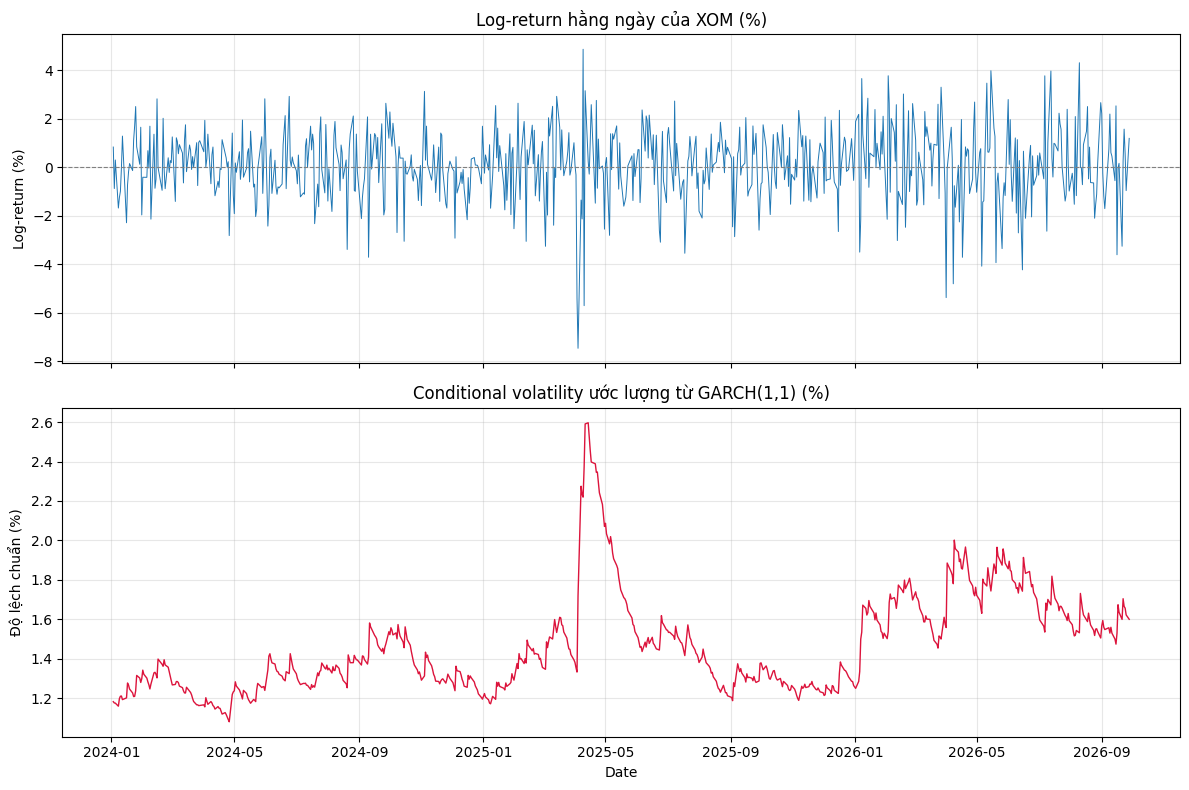

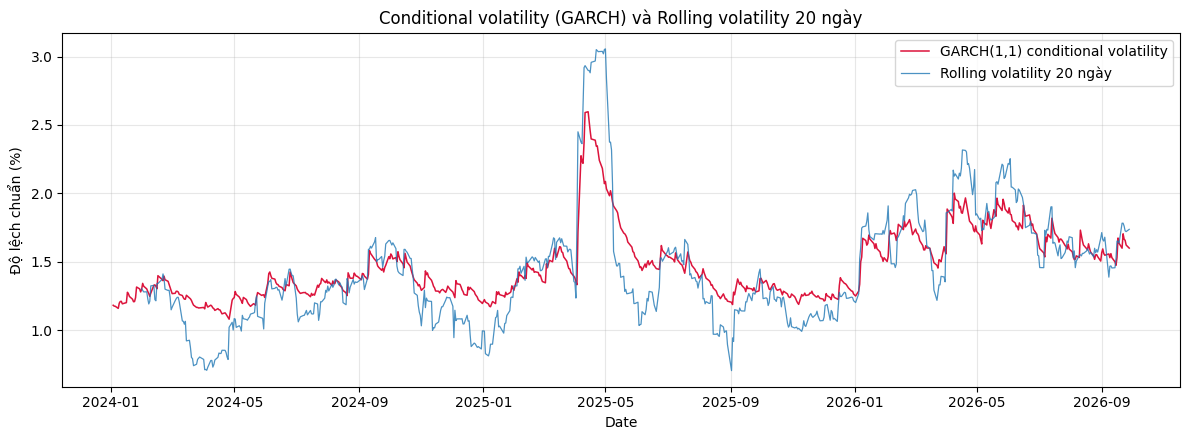

Conditional volatility cao nhất : 2.5966% vào 2025-04-14
Conditional volatility thấp nhất: 1.0794% vào 2024-04-26
Tương quan GARCH vs Rolling 20D : 0.924


In [8]:
cv = res.conditional_volatility          # σₜ (%)
roll20 = r.rolling(20).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(r, linewidth=0.7)
ax[0].axhline(0, linestyle="--", linewidth=0.8, color="gray")
ax[0].set_title("Log-return hằng ngày của XOM (%)")
ax[0].set_ylabel("Log-return (%)")
ax[1].plot(cv, color="crimson", linewidth=1)
ax[1].set_title("Conditional volatility ước lượng từ GARCH(1,1) (%)")
ax[1].set_ylabel("Độ lệch chuẩn (%)")
ax[1].set_xlabel("Date")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/hinh_4_1.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 4.5))
plt.plot(cv, color="crimson", linewidth=1.1, label="GARCH(1,1) conditional volatility")
plt.plot(roll20, linewidth=0.9, alpha=0.8, label="Rolling volatility 20 ngày")
plt.title("Conditional volatility (GARCH) và Rolling volatility 20 ngày")
plt.xlabel("Date")
plt.ylabel("Độ lệch chuẩn (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/hinh_4_2.png", dpi=200)
plt.show()

print(f"Conditional volatility cao nhất : {cv.max():.4f}% vào {cv.idxmax().date()}")
print(f"Conditional volatility thấp nhất: {cv.min():.4f}% vào {cv.idxmin().date()}")
print(f"Tương quan GARCH vs Rolling 20D : {cv.corr(roll20):.3f}")

In [9]:
# Đối chiếu với các giai đoạn nổi bật ở Phần 2 (Bảng 3.1)
monthly = pd.DataFrame({
    "Std thực tế theo tháng (%)": r.groupby(r.index.to_period("M")).std(),
    "Cond. vol trung bình tháng (%)": cv.groupby(cv.index.to_period("M")).mean(),
})
key_months = ["2024-03", "2024-12", "2025-04", "2025-08",
              "2026-02", "2026-04", "2026-05", "2026-06"]
display(monthly.loc[key_months].round(4))

print("Cond. vol trung bình theo năm (%):")
display(cv.groupby(cv.index.year).mean().round(4).to_frame("Cond. vol (%)"))
print("Các tháng có conditional volatility trung bình cao nhất:")
display(monthly.sort_values("Cond. vol trung bình tháng (%)", ascending=False).head(6).round(4))

,Std thực tế theo tháng (%),Cond. vol trung bình tháng (%)
Date,,
2024-03,0.8028,1.2275
2024-12,0.9718,1.2781
2025-04,2.9787,2.1638
2025-08,0.9807,1.3122
2026-02,2.0759,1.7117
2026-04,2.1195,1.8417
2026-05,2.1196,1.8185
2026-06,1.6663,1.7952


Cond. vol trung bình theo năm (%):


,Cond. vol (%)
Date,
2024,1.3080
2025,1.4630
2026,1.6795


Các tháng có conditional volatility trung bình cao nhất:


,Std thực tế theo tháng (%),Cond. vol trung bình tháng (%)
Date,,
2025-04,2.9787,2.1638
2026-04,2.1195,1.8417
2026-05,2.1196,1.8185
2025-05,1.1652,1.7967
2026-06,1.6663,1.7952
2026-02,2.0759,1.7117


In [10]:
# Kiểm tra chẩn đoán: phần dư chuẩn hóa còn ARCH effect không?
std_resid = res.std_resid.dropna()

lb_before = acorr_ljungbox(resid**2, lags=[5, 10, 20], return_df=True)
lb_after  = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)
lm_b = het_arch(resid, nlags=5)
lm_a = het_arch(std_resid, nlags=5)

diag = pd.DataFrame({
    "Trước GARCH (thống kê)": [lm_b[0]] + lb_before["lb_stat"].tolist(),
    "Trước GARCH (p-value)":  [lm_b[1]] + lb_before["lb_pvalue"].tolist(),
    "Sau GARCH (thống kê)":   [lm_a[0]] + lb_after["lb_stat"].tolist(),
    "Sau GARCH (p-value)":    [lm_a[1]] + lb_after["lb_pvalue"].tolist(),
}, index=["ARCH-LM (5 lags)", "Ljung-Box r² (lag 5)", "Ljung-Box r² (lag 10)", "Ljung-Box r² (lag 20)"])
display(diag.style.format("{:.4f}"))

print("Ljung-Box trên phần dư chuẩn hóa (mức trung bình), lag 10:")
display(acorr_ljungbox(std_resid, lags=[10], return_df=True))
print(f"Excess kurtosis: return gốc = {r.kurt():.2f} | phần dư chuẩn hóa = {std_resid.kurt():.2f}")

,Trước GARCH (thống kê),Trước GARCH (p-value),Sau GARCH (thống kê),Sau GARCH (p-value)
ARCH-LM (5 lags),59.8660,0.0000,13.8244,0.0168
Ljung-Box r² (lag 5),78.0847,0.0000,13.6849,0.0177
Ljung-Box r² (lag 10),81.2159,0.0000,18.4301,0.0481
Ljung-Box r² (lag 20),97.1670,0.0000,30.6439,0.0601


Ljung-Box trên phần dư chuẩn hóa (mức trung bình), lag 10:


,lb_stat,lb_pvalue
10,6.254056,0.793486


Excess kurtosis: return gốc = 1.73 | phần dư chuẩn hóa = 0.96


**Nhận xét:**

- **Cụm 04/2025:** conditional volatility trung bình tháng 04/2025 là 2,1638%, cao nhất mẫu; đỉnh 2,5966% vào ngày 14/04/2025, sau chuỗi phiên biến động mạnh (03/04, 04/04, 09/04, 10/04). Sau đỉnh, σₜ giảm chậm.
- **2026:** các tháng 02, 04, 05, 06/2026 có conditional volatility ở mức cao (1,71% đến 1,84%), và trung bình năm tăng từ 1,31% (2024) lên 1,46% (2025) và 1,68% (2026).
- **Giai đoạn thấp (03/2024, 12/2024, 08/2025):** conditional volatility thấp hơn rõ rệt (1,23% đến 1,31%).
- **So với Rolling 20D:** tương quan 0,924; GARCH mượt hơn và giảm dần theo β₁, còn Rolling 20D đạt đỉnh cao hơn rồi tụt nhanh khi các phiên biến động rời cửa sổ.
- **Hạn chế:** GARCH ước lượng thấp hơn thực tế ở đỉnh cực đoan (04/2025: 2,16% so với 2,98%) và cao hơn ở giai đoạn yên ắng (03/2024: 1,23% so với 0,80%).
- **Chẩn đoán:** các thống kê giảm mạnh sau GARCH nhưng ARCH-LM (p ≈ 0,017) và Ljung-Box lag 5, 10 vẫn nhỏ hơn 5%, nên GARCH(1,1) hấp thụ phần lớn nhưng chưa hoàn toàn ARCH effect.

## 4.6. Giới hạn dự báo GARCH

GARCH là dự báo **có điều kiện**: σₜ² chỉ phụ thuộc vào εₜ₋₁² và σₜ₋₁², tức phụ thuộc vào thông tin lịch sử. Vì vậy mô hình phản ứng sau cú sốc chứ không báo trước được cú sốc mới.

In [11]:
# Cụm biến động tháng 04/2025: σₜ trước và sau các cú sốc
window = pd.DataFrame({
    "XOM_Return (%)": r,
    "Cond. vol σₜ (%)": cv,
    "Phần dư chuẩn hóa zₜ": res.std_resid,
}).loc["2025-04-02":"2025-04-14"]
display(window.style.format({"XOM_Return (%)": "{:.2f}",
                             "Cond. vol σₜ (%)": "{:.3f}",
                             "Phần dư chuẩn hóa zₜ": "{:.2f}"}))

s03, s04, s07 = cv["2025-04-03"], cv["2025-04-04"], cv["2025-04-07"]
print(f"σ ngày 03/04 (trước cú sốc): {s03:.3f}% | 04/04: {s04:.3f}% (+{s04/s03-1:.0%}) | 07/04: {s07:.3f}% (+{s07/s03-1:.0%})")

,XOM_Return (%),Cond. vol σₜ (%),Phần dư chuẩn hóa zₜ
Date,,,
2025-04-02 00:00:00,-0.31,1.354,-0.28
2025-04-03 00:00:00,-5.40,1.332,-4.11
2025-04-04 00:00:00,-7.47,1.718,-4.38
2025-04-07 00:00:00,-1.35,2.275,-0.62
2025-04-08 00:00:00,-2.13,2.233,-0.98
2025-04-09 00:00:00,4.87,2.219,2.16
2025-04-10 00:00:00,-5.71,2.372,-2.43
2025-04-11 00:00:00,3.16,2.591,1.19
2025-04-14 00:00:00,0.24,2.597,0.07


σ ngày 03/04 (trước cú sốc): 1.332% | 04/04: 1.718% (+29%) | 07/04: 2.275% (+71%)


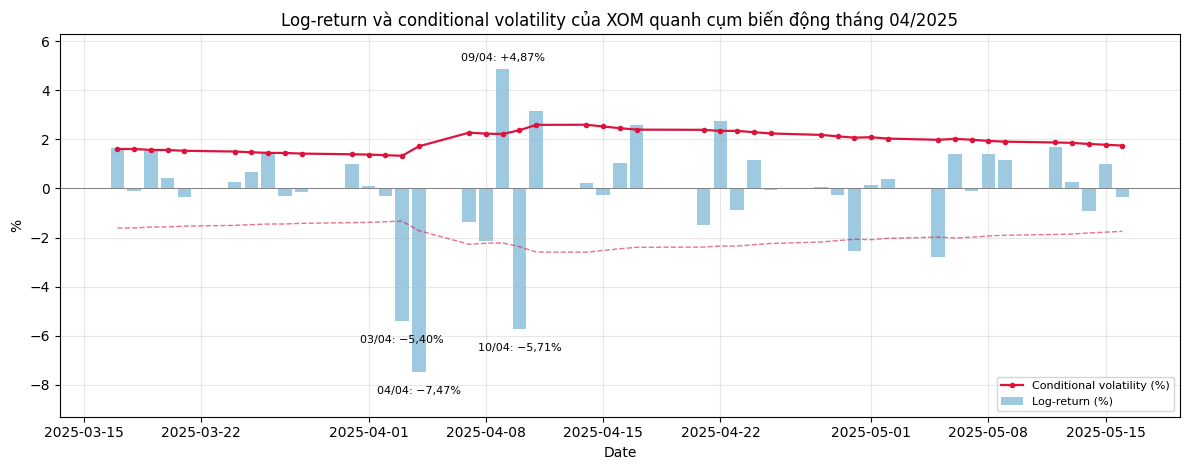

In [12]:
sub = pd.DataFrame({"r": r, "cv": cv}).loc["2025-03-17":"2025-05-16"]

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(sub.index, sub["r"], color="#9ecae1", width=0.8, label="Log-return (%)")
ax.plot(sub["cv"], color="crimson", linewidth=1.6, marker="o", markersize=3, label="Conditional volatility (%)")
ax.plot(-sub["cv"], color="crimson", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(0, color="gray", linewidth=0.7)
for d, t, dy in [("2025-04-03", "03/04: −5,40%", -16), ("2025-04-04", "04/04: −7,47%", -16),
                 ("2025-04-09", "09/04: +4,87%", 6), ("2025-04-10", "10/04: −5,71%", -16)]:
    ax.annotate(t, (pd.Timestamp(d), sub.loc[d, "r"]), textcoords="offset points",
                xytext=(0, dy), ha="center", fontsize=8)
ax.set_ylim(-9.3, 6.3)
ax.set_title("Log-return và conditional volatility của XOM quanh cụm biến động tháng 04/2025")
ax.set_xlabel("Date")
ax.set_ylabel("%")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/hinh_4_3.png", dpi=200)
plt.show()

,Độ lệch chuẩn dự báo (%)
h = 1,1.581
h = 2,1.580
h = 3,1.579
h = 4,1.577
h = 5,1.576
h = 6,1.575
h = 7,1.574
h = 8,1.573
h = 9,1.572
h = 10,1.571


σ quan sát ngày cuối (2026-09-28): 1.599%
Mức dài hạn √[ω/(1−α₁−β₁)]: 1.518%


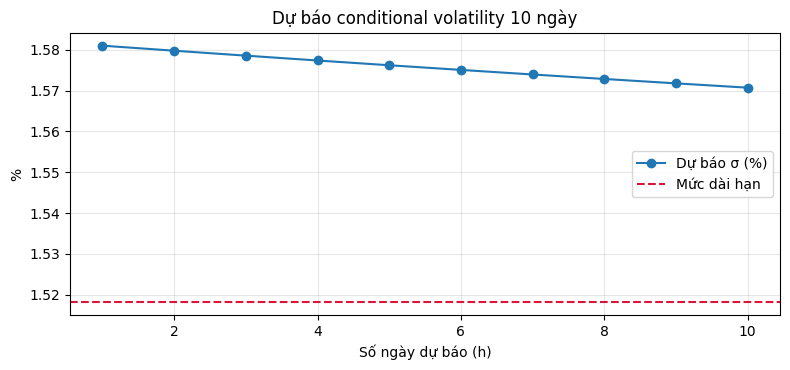

In [13]:
# Dự báo 10 ngày: hội tụ về mức phương sai dài hạn
fc = res.forecast(horizon=10).variance.iloc[-1] ** 0.5
fc_table = pd.DataFrame({"Độ lệch chuẩn dự báo (%)": fc.values},
                        index=[f"h = {h}" for h in range(1, 11)])
display(fc_table.round(3))
print(f"σ quan sát ngày cuối ({cv.index[-1].date()}): {cv.iloc[-1]:.3f}%")
print(f"Mức dài hạn √[ω/(1−α₁−β₁)]: {np.sqrt(lr_var):.3f}%")

plt.figure(figsize=(8, 3.8))
plt.plot(range(1, 11), fc.values, marker="o", label="Dự báo σ (%)")
plt.axhline(np.sqrt(lr_var), color="crimson", linestyle="--", label="Mức dài hạn")
plt.title("Dự báo conditional volatility 10 ngày")
plt.xlabel("Số ngày dự báo (h)")
plt.ylabel("%")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:**

- Ngày 03/04/2025, σₜ chỉ là 1,33% (tính từ thông tin đến 02/04) nên cú giảm −5,40% ứng với zₜ ≈ −4,1. Chỉ sau khi cú sốc xảy ra, σₜ mới tăng lên 1,72% (04/04) và 2,27% (07/04). Mô hình **phản ứng sau cú sốc, không báo trước cú sốc**.
- Các phiên 09/04 (+4,87%) và 10/04 (−5,71%) có độ lớn tương đương nhưng chỉ ứng với zₜ ≈ 2,2 và −2,4, vì σₜ đã tăng: đây là volatility clustering.
- Dự báo nhiều bước hội tụ chậm về mức dài hạn (≈ 1,52%/ngày) do half-life khoảng 34 ngày; dự báo 10 ngày gần như đi ngang.
- **Các giới hạn chính:** (1) phụ thuộc hoàn toàn vào dữ liệu lịch sử, không dự đoán được cú sốc hoàn toàn mới như quyết định OPEC+, thuế quan hay gián đoạn Hormuz; (2) mô hình đối xứng, không phân biệt tin xấu và tin tốt (hướng mở rộng: EGARCH, GJR-GARCH); (3) đặc tả đơn giản và phần dư chuẩn hóa vẫn còn ARCH nhẹ; (4) trùng thời điểm với sự kiện thị trường không đủ để kết luận quan hệ nhân quả.

## 4.7. Kết luận Phần 3

ARCH-LM xác nhận chuỗi XOM_Return có ARCH effect (p < 0,001). GARCH(1,1) cho α₁ = 0,0415, β₁ = 0,9384, persistence 0,9800 và half-life khoảng 34,3 ngày, cho thấy volatility của XOM có tính bền cao. Conditional volatility bám theo các cụm biến động cao ở 04/2025 và năm 2026 nhưng mượt hơn dữ liệu thực và phần dư chuẩn hóa vẫn còn dấu hiệu ARCH nhẹ. Dự báo của GARCH là dự báo có điều kiện dựa trên lịch sử: mô hình không báo trước được các cú sốc hoàn toàn mới, nên GARCH hỗ trợ mô hình hóa rủi ro thay đổi theo thời gian nhưng không phải công cụ dự đoán chắc chắn tương lai.

In [14]:
# Bảng số liệu tóm tắt bàn giao cho Phần 5 (Tổng kết)
handover = pd.DataFrame({
    "Kết quả": [
        f"LM = {het_arch(resid, nlags=5)[0]:.3f}, p = {het_arch(resid, nlags=5)[1]:.2e}",
        f"{omega:.4f} (p = {res.pvalues['omega']:.3f})",
        f"{alpha:.4f} (p = {res.pvalues['alpha[1]']:.4f})",
        f"{beta:.4f} (p < 0.001)",
        f"{persistence:.4f}",
        f"{half_life:.1f} ngày",
        f"{cv.max():.4f}% ({cv.idxmax().date()})",
    ]
}, index=["ARCH-LM (5 lags)", "ω", "α₁", "β₁", "α₁+β₁", "Half-life", "Cond. vol cao nhất"])
display(handover)

,Kết quả
ARCH-LM (5 lags),"LM = 59.866, p = 1.30e-11"
ω,0.0461 (p = 0.198)
α₁,0.0415 (p = 0.0375)
β₁,0.9384 (p < 0.001)
α₁+β₁,0.9800
Half-life,34.3 ngày
Cond. vol cao nhất,2.5966% (2025-04-14)
